# 02 - Feature engineering

**Revision note (leak post-mortem upstream of everything below).** The first version
of this notebook reconstructed the per-athlete daily series and built 7d/28d rolling
load features plus the acute:chronic workload ratio. Those features produced a 0.987
validation AUC in 03 - which our own red-flag checklist says to treat as evidence of
leakage, not brilliance. The autopsy found the cause in the dataset's construction,
not our code: **the publishers removed all rows for at least 22 days before every
injury** (evidence below). Any feature window reaching beyond the row's own 7 days
therefore lands in a guaranteed row-desert for injury rows only - the model was
reading the publishers' sampling scheme, not training physiology. Chronic load and
ACWR are not computable without artifact on this dataset, in any framing. The full
catch-story is in 03; git history preserves the original version.

What stands in v2:

- The daily-series reconstruction (unchanged - it is how the artifact was found and
  it validates the table's structure)
- Features computed **from each row's own window only**: prospective = days
  t-1..t-6 (6 days, identical for every row), same-day = days t..t-6 (7 days,
  the paper's framing). Symmetric by construction - no coverage gates needed, no
  missing-window beacons possible.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path('../data/raw')
OUT = Path('../data/processed')
OUT.mkdir(exist_ok=True)

BASE = ['nr. sessions', 'total km', 'km Z3-4', 'km Z5-T1-T2', 'km sprinting',
        'strength training', 'hours alternative', 'perceived exertion',
        'perceived trainingSuccess', 'perceived recovery']

day = pd.read_csv(RAW / 'day_approach_maskedID_timeseries.csv.gz')
print(day.shape)

(42766, 73)


## 1. Daily-series reconstruction (validation + the discovery instrument)

Row at `Date` t carries slots for days t-6..t (slot k -> day t-(6-k); `.6` = day t,
proven in 01). The windows overlap, so the daily series is recoverable and every
overlap must agree - if it does not, the structural reading is wrong.

In [2]:
blocks = []
for k in range(7):
    cols = BASE if k == 0 else [f'{b}.{k}' for b in BASE]
    blk = day[cols].copy()
    blk.columns = BASE
    blk['Athlete ID'] = day['Athlete ID'].values
    blk['day'] = day['Date'].values - (6 - k)
    blocks.append(blk)
long = pd.concat(blocks, ignore_index=True)

g = long.groupby(['Athlete ID', 'day'])[BASE]
spread = (g.max() - g.min()).abs().to_numpy().max()
print('slot records:', len(long), '| max disagreement across overlaps:', spread)
assert spread < 1e-9
daily = g.first().reset_index()
print('daily records:', len(daily), '| athletes:', daily['Athlete ID'].nunique())
print('(negative day indices are real pre-Date-0 history, kept - see 01/assumptions log)')
daily.to_csv(OUT / 'daily_series.csv.gz', index=False)

slot records: 299362 | max disagreement across overlaps: 0.0
daily records: 49162 | athletes: 74
(negative day indices are real pre-Date-0 history, kept - see 01/assumptions log)


## 2. The publisher's injury buffer - why long windows are forbidden

The decisive data property, found while hunting 03's too-good-to-be-true AUC:
how long before each row was the same athlete's PREVIOUS row?

days since athlete's previous row:
  injury rows : min 22, median 22
  healthy rows: median 1 | share with a row <= 7 days before: 98.9%
  injury rows with a row <= 7 days before: 0 of 583


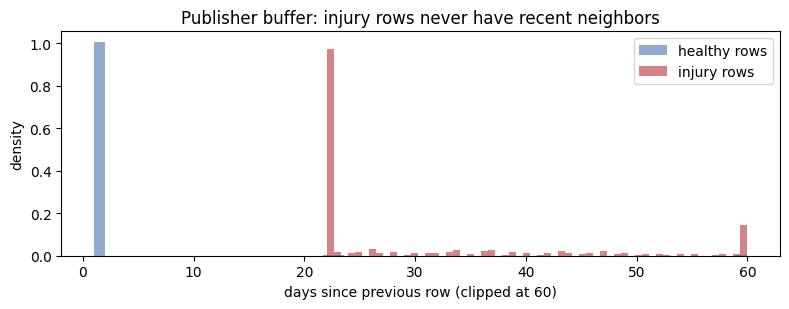

In [3]:
d = day.sort_values(['Athlete ID', 'Date'])
d['prev_row_gap'] = d.groupby('Athlete ID').Date.diff()
pos, neg = d[d.injury == 1], d[d.injury == 0]
print('days since athlete\'s previous row:')
print('  injury rows : min %d, median %.0f' % (pos.prev_row_gap.min(), pos.prev_row_gap.median()))
print('  healthy rows: median %.0f | share with a row <= 7 days before: %.1f%%'
      % (neg.prev_row_gap.median(), 100 * (neg.prev_row_gap <= 7).mean()))
print('  injury rows with a row <= 7 days before:', int((pos.prev_row_gap <= 7).sum()),
      'of', len(pos))

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(np.clip(neg.prev_row_gap.dropna(), 0, 60), bins=60, alpha=.6,
        label='healthy rows', color='#4C72B0', density=True)
ax.hist(np.clip(pos.prev_row_gap.dropna(), 0, 60), bins=60, alpha=.7,
        label='injury rows', color='#C44E52', density=True)
ax.set_xlabel('days since previous row (clipped at 60)'); ax.set_ylabel('density')
ax.legend(); ax.set_title('Publisher buffer: injury rows never have recent neighbors')
plt.tight_layout()

**Consequence.** Every injury row's previous row is >= 22 days back (median 22);
98.9% of healthy rows have one 1 day back. So any feature that needs information
from before day t-6 - a 28-day chronic load, a 14-day rest count, a week-over-week
change - is systematically unavailable for positives and available for negatives.
However you handle that gap (NaN flags, imputation, zero-fill, row-dropping), the
handling itself encodes the label. v1 measured this the hard way: the missing-ness
beacon alone drove validation AUC to 0.987, and complete-case analysis would have
deleted all 583 positives.

The honest feature space is therefore **the row's own window and nothing else**.

## 3. Features - two framings from each row's own slots

Slot map (01, proven): `.6` = day t, `.5` = t-1, ..., unsuffixed = t-6.

- `__pros` (prospective, headline): slots t-1..t-6 - 6 days, symmetric for every
  row, nothing from the prediction day itself
- `__same` (same-day, benchmark-comparable): slots t..t-6 - all 7 days, the
  paper's framing

12 features per framing:

| feature | definition |
|---|---|
| `km_sum`, `sessions` | total km / session count in window |
| `km_mod`, `km_hi` | km in Z3-4 / km in Z5-T1-T2 + sprint |
| `pct_mod`, `pct_hi` | shares of `km_sum` (NaN when `km_sum` = 0 - a real zero-running window, value-based and symmetric, handled by impute+flag in 03 per the logged decision) |
| `rest_days` | days in window with 0 sessions |
| `strength_n`, `alt_hours` | strength sessions / alternative-training hours |
| `exertion_avg`, `recovery_avg`, `success_avg` | means of the subjective 0-1 scores |

Lost with the long windows, stated plainly: chronic load, ACWR, 14-day recovery
patterns, week-over-week change. That is a real modeling cost - the price of
features the sampling scheme cannot support honestly.

In [4]:
def window_features(slot_range, suffix):
    slot = lambda b, k: day[b] if k == 0 else day[f'{b}.{k}']
    stack = {b: pd.concat([slot(b, k) for k in slot_range], axis=1) for b in BASE}
    f = pd.DataFrame(index=day.index)
    f['km_sum']   = stack['total km'].sum(axis=1)
    f['sessions'] = stack['nr. sessions'].sum(axis=1)
    f['km_mod']   = stack['km Z3-4'].sum(axis=1)
    f['km_hi']    = stack['km Z5-T1-T2'].sum(axis=1) + stack['km sprinting'].sum(axis=1)
    f['pct_mod']  = f['km_mod'] / f['km_sum'].replace(0, np.nan)
    f['pct_hi']   = f['km_hi']  / f['km_sum'].replace(0, np.nan)
    f['rest_days'] = (stack['nr. sessions'] == 0).sum(axis=1)
    f['strength_n'] = stack['strength training'].sum(axis=1)
    f['alt_hours']  = stack['hours alternative'].sum(axis=1)
    f['exertion_avg'] = stack['perceived exertion'].mean(axis=1)
    f['recovery_avg'] = stack['perceived recovery'].mean(axis=1)
    f['success_avg']  = stack['perceived trainingSuccess'].mean(axis=1)
    return f.add_suffix(suffix)

pros = window_features(range(0, 6), '__pros')   # slots t-6..t-1
same = window_features(range(0, 7), '__same')   # slots t-6..t
X = pd.concat([day[['Athlete ID', 'Date', 'injury']], same, pros], axis=1)
print(X.shape, '| positives:', int(X.injury.sum()))

(42766, 27) | positives: 583


In [5]:
# Symmetry audit - the check that would have caught v1's artifact at birth:
# every feature's NaN rate, injury vs healthy. Anything asymmetric beyond the
# value-based pct features is a red flag.
featcols = [c for c in X.columns if '__' in c]
audit = pd.DataFrame({
    'pos_nan': X[X.injury == 1][featcols].isna().mean(),
    'neg_nan': X[X.injury == 0][featcols].isna().mean(),
})
print(audit[audit.max(axis=1) > 0].round(4).to_string())
print('\nfeatures with any NaN:', int((audit.max(axis=1) > 0).sum()), 'of', len(featcols))
assert (audit.drop(index=[c for c in featcols if 'pct' in c]).max(axis=1) == 0).all(), \
    'non-pct feature has NaN - investigate before proceeding'

               pos_nan  neg_nan
pct_mod__same   0.0343   0.1019
pct_hi__same    0.0343   0.1019
pct_mod__pros   0.0343   0.1088
pct_hi__pros    0.0343   0.1088

features with any NaN: 4 of 24


In [6]:
# Sanity anchor: same-day km_sum must equal the row's own 7-slot total km sum.
slot_total = sum(day['total km'] if k == 0 else day[f'total km.{k}'] for k in range(7))
err = (X['km_sum__same'] - slot_total).abs().max()
print('max |km_sum__same - direct slot sum| =', err)
assert err < 1e-9
X.to_csv(OUT / 'features_day.csv.gz', index=False)
print('wrote', OUT / 'features_day.csv.gz', X.shape)

max |km_sum__same - direct slot sum| = 0.0


wrote ../data/processed/features_day.csv.gz (42766, 27)


## Summary

- Reconstruction validated (exact); the publisher's >= 22-day pre-injury buffer is
  demonstrated and is now a structural constraint on all feature design.
- 12 features x 2 framings, computed from each row's own window only: prospective =
  6 days t-1..t-6, same-day = 7 days t..t-6. Symmetric by construction; the NaN
  audit shows only the value-based pct features (zero-running windows) carry NaN,
  in the direction physiology predicts (healthy rows have more zero-running weeks).
- Chronic load / ACWR / week-over-week features documented as honestly
  unbuildable here - the project's "what I tried that failed" exhibit, with the
  0.987-AUC catch story in 03.